# Visualization of key patterns in flight data

### Step 1 : data insception and preprocessing

In [1]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
# configure data display options
pd.set_option("display.max_columns", None)
sb.set_style("whitegrid")

In [2]:
# load the dataset 
df = pd.read_csv("data/flights.csv")
# verifying through first five rows of the dataset
df.head()

,origin,destination,departure_date,return_date,origin_airport,destination_airport,airline,stops,departure_time,arrival_time,duration(in minutes),price,currency
0,Kathmandu,Hong Kong,2026-05-14,2026-05-26,Tribhuvan International Airport,Hong Kong International Airport,THAI and Cathay Pacific,2,1:30 PM,5:50 AM,845,1053836,NPR
1,Kathmandu,Shanghai,2026-05-17,2026-05-27,Tribhuvan International Airport,Shanghai Pudong International Airport,China Southern,1,12:30 PM,12:20 AM,575,98594,NPR
2,Paris,Shanghai,2026-05-07,2026-05-16,Charles de Gaulle Airport,Shanghai Pudong International Airport,Turkish Airlines,1,4:00 AM,9:00 PM,1064,83326,NPR
3,Kathmandu,Shanghai,2026-06-25,2026-07-03,Tribhuvan International Airport,Shanghai Pudong International Airport,flydubai and Emirates,2,12:15 AM,10:45 PM,651,521029,NPR
4,Singapore,Frankfurt,2026-02-21,2026-02-26,Changi Airport,Frankfurt Airport,Turkish Airlines,1,4:00 AM,8:45 AM,1287,144200,NPR


In [3]:
# Basic inspection - checking shape,columns,overview,null and duplicates in the dataset 
df.shape
df.columns
df.info()
df.describe(include="all")
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1004 entries, 0 to 1003
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   origin                1004 non-null   str  
 1   destination           1004 non-null   str  
 2   departure_date        1004 non-null   str  
 3   return_date           1004 non-null   str  
 4   origin_airport        1004 non-null   str  
 5   destination_airport   1004 non-null   str  
 6   airline               1004 non-null   str  
 7   stops                 1004 non-null   int64
 8   departure_time        1004 non-null   str  
 9   arrival_time          1004 non-null   str  
 10  duration(in minutes)  1004 non-null   int64
 11  price                 1004 non-null   int64
 12  currency              1004 non-null   str  
dtypes: int64(3), str(10)
memory usage: 102.1 KB


np.int64(0)

In [4]:
# data cleaning converting departure_date and return_date into datetime values 
df["departure_date"] = pd.to_datetime(df["departure_date"])
df["return_date"] = pd.to_datetime(df["return_date"])
#verification 
print(df[["departure_date", "return_date"]].dtypes)

departure_date    datetime64[us]
return_date       datetime64[us]
dtype: object


In [5]:
# Feature enginerring - trip_length and price per minutes
df["trip_length"] = (
    df["return_date"] - df["departure_date"]
).dt.days
df["price_per_minutes"] = (df["price"]/df["duration(in minutes)"])
df["price_per_stop"] = np.where(
    df["stops"] >= 1,
    df["price"] / df["stops"],
    df["price"]
)
#verification
df[["trip_length","price_per_minutes","price_per_stop"]].head()

,trip_length,price_per_minutes,price_per_stop
0,12,1247.143195,526918.0
1,10,171.467826,98594.0
2,9,78.313910,83326.0
3,8,800.351767,260514.5
4,5,112.043512,144200.0


### Step 2: Data loading and visualizations

### Univariate Analysis

<Axes: xlabel='price_per_stop', ylabel='Count'>

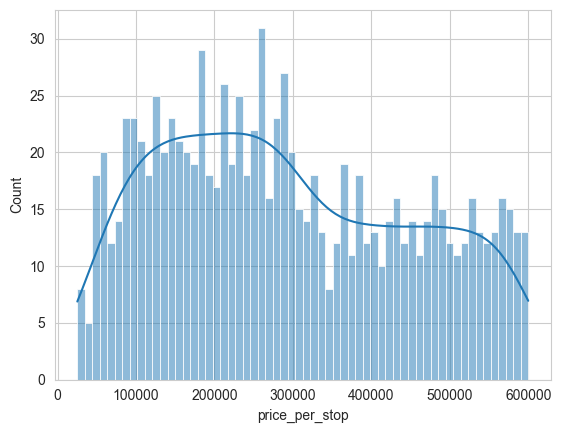

In [ ]:
# Price distribution by stops
sb.histplot(df["price_per_stop"],bins=60,kde=True) 

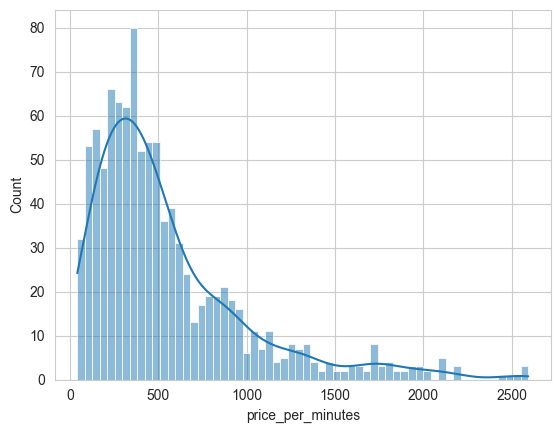

In [7]:
# Price distribution(by minutes)
sb.histplot(df["price_per_minutes"], bins=60, kde=True)
plt.show()

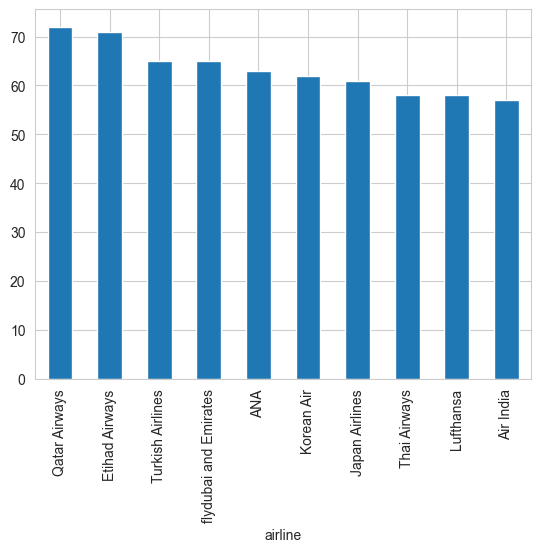

In [8]:
# Top 10 Airlines 
df["airline"].value_counts().head(10).plot(kind="bar")
plt.show()

### Bivariate analysis 

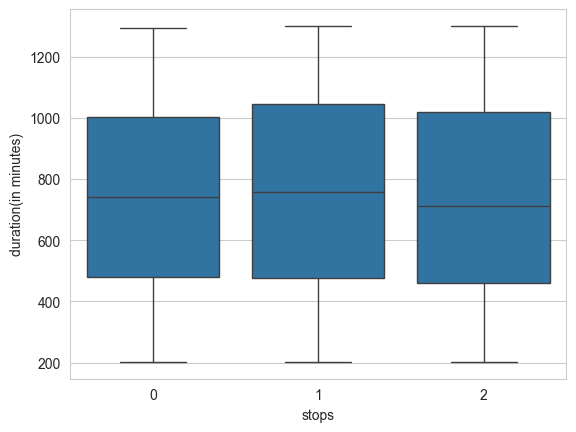

In [9]:
# stops vs duration(in minutes) 
sb.boxplot(x="stops", y="duration(in minutes)", data=df)
plt.show()

<b>Interpretation:</b> Almost all flights have similar ranges of duration in minutes between approx 500 to 1000 regardless of their number of stops. Only some flights with stops 1 seem to range slightly higher above 1000 minutes duration.

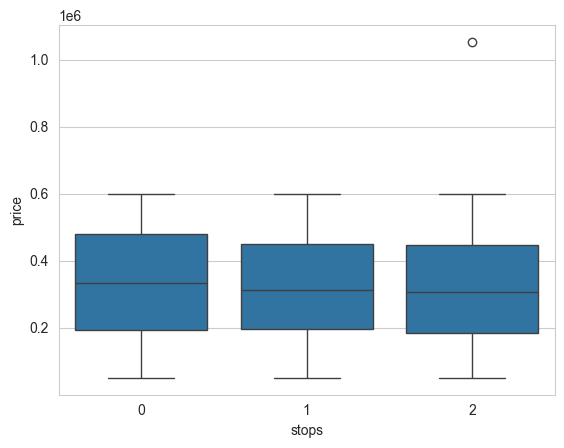

In [12]:
# Price vs stops 
sb.boxplot(x="stops", y="price", data=df)
plt.show()

Note : Above plot respresents price in range of lakhs i.e. 0.2 lakhs is equal to 20 thousand<br>
<b>Interpretation:</b> Almost all flights have similar offered ranges of price between 20 to 60 thousand regardless of the number of stops. It shows low difference in price in relation to the change in the number of stops.

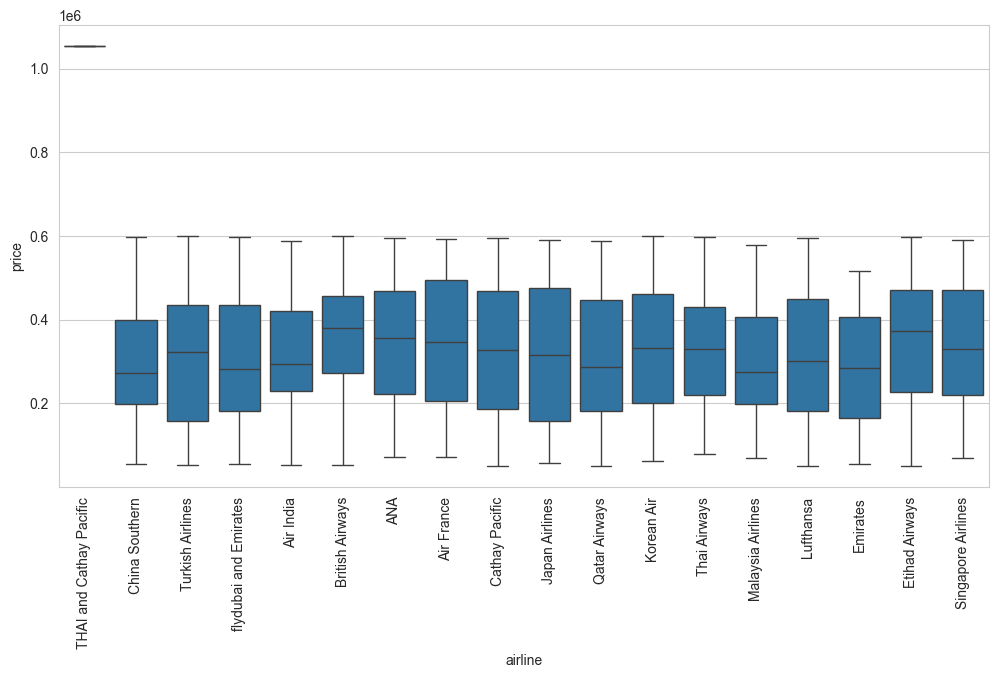

In [10]:
# Price vs Airline 
plt.figure(figsize=(12, 6))
sb.boxplot(x="airline", y="price", data=df)
plt.xticks(rotation=90)
plt.show()

Note : Above plot respresents price in range of lakhs i.e. 0.2 lakhs is equal to 20 thousand<br>
<b>Interpretation:</b> Almost all airline have similar offered ranges of price between 20 to 60 thousand regardless determining high competition between airlines in a close time period.